In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

In [2]:
##Connection:

server = r"LAPTOP-71G1NMQR\SQLEXPRESS"
database = "AQI_Analytics"

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

In [3]:
##Data load:

query = """
SELECT *
FROM dbo.AQI_Data
"""

df = pd.read_sql(query, engine)

In [4]:
df.shape

(54000, 22)

In [5]:
df.head()

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,city,state,...,date,year,month,day,hour,day_of_week,day_name,aqi_category,time_period,season
0,2026-08-01 00:00:00,28.6,29.5,410.0,24.4,19.2,59.0,89,Delhi,Delhi,...,2026-08-01,2026,8,1,0,5,Saturday,Moderate,Night,Monsoon
1,2026-08-01 01:00:00,41.2,157.9,358.0,21.2,18.2,61.0,88,Delhi,Delhi,...,2026-08-01,2026,8,1,1,5,Saturday,Moderate,Night,Monsoon
2,2026-08-01 02:00:00,49.4,225.8,321.0,18.9,17.7,62.0,88,Delhi,Delhi,...,2026-08-01,2026,8,1,2,5,Saturday,Moderate,Night,Monsoon
3,2026-08-01 03:00:00,52.9,252.4,299.0,18.2,17.9,59.0,89,Delhi,Delhi,...,2026-08-01,2026,8,1,3,5,Saturday,Moderate,Night,Monsoon
4,2026-08-01 04:00:00,52.4,243.1,292.0,18.4,18.6,56.0,91,Delhi,Delhi,...,2026-08-01,2026,8,1,4,5,Saturday,Moderate,Night,Monsoon


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              54000 non-null  str    
 1   pm2_5             54000 non-null  float64
 2   pm10              54000 non-null  float64
 3   carbon_monoxide   54000 non-null  float64
 4   nitrogen_dioxide  54000 non-null  float64
 5   sulphur_dioxide   54000 non-null  float64
 6   ozone             54000 non-null  float64
 7   us_aqi            54000 non-null  int64  
 8   city              54000 non-null  str    
 9   state             54000 non-null  str    
 10  latitude          54000 non-null  float64
 11  longitude         54000 non-null  float64
 12  date              54000 non-null  str    
 13  year              54000 non-null  int64  
 14  month             54000 non-null  int64  
 15  day               54000 non-null  int64  
 16  hour              54000 non-null  int64  
 17  day_

Univariate Analysis

In [7]:
df.describe()

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,latitude,longitude,year,month,day,hour,day_of_week
count,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.0,54000.000000,54000.000000,54000.000000,54000.000000
mean,24.163824,36.074291,311.543407,12.040598,10.049435,72.063685,79.510426,22.376256,78.422190,2026.0,8.311111,13.355556,11.500000,3.044444
std,18.632200,38.655849,231.453573,12.123798,11.481964,39.809838,34.183841,6.295588,4.547476,0.0,0.462952,8.697859,6.922251,2.054343
min,0.700000,0.800000,78.000000,0.000000,0.000000,0.000000,15.000000,8.524100,70.802200,2026.0,8.000000,1.000000,0.000000,0.000000
25%,11.800000,16.600000,167.000000,4.300000,3.800000,43.000000,57.000000,19.076000,74.872300,2026.0,8.000000,6.000000,5.750000,1.000000
50%,19.400000,26.800000,252.000000,8.300000,6.400000,63.000000,72.000000,22.871050,77.310800,2026.0,8.000000,12.000000,11.500000,3.000000
75%,30.500000,41.800000,369.000000,15.100000,11.100000,92.000000,93.000000,26.449900,80.946200,2026.0,9.000000,20.000000,17.250000,5.000000
max,192.800000,687.300000,3302.000000,113.800000,146.300000,311.000000,418.000000,34.083700,91.736200,2026.0,9.000000,31.000000,23.000000,6.000000


In [8]:
df.isnull().sum()

time                0
pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
us_aqi              0
city                0
state               0
latitude            0
longitude           0
date                0
year                0
month               0
day                 0
hour                0
day_of_week         0
day_name            0
aqi_category        0
time_period         0
season              0
dtype: int64

In [9]:
##Understand numerical variables
numeric_cols = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "us_aqi"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pm2_5,54000.0,24.163824,18.632200,0.7,11.8,19.4,30.5,192.8
pm10,54000.0,36.074291,38.655849,0.8,16.6,26.8,41.8,687.3
carbon_monoxide,54000.0,311.543407,231.453573,78.0,167.0,252.0,369.0,3302.0
nitrogen_dioxide,54000.0,12.040598,12.123798,0.0,4.3,8.3,15.1,113.8
sulphur_dioxide,54000.0,10.049435,11.481964,0.0,3.8,6.4,11.1,146.3
ozone,54000.0,72.063685,39.809838,0.0,43.0,63.0,92.0,311.0
us_aqi,54000.0,79.510426,34.183841,15.0,57.0,72.0,93.0,418.0


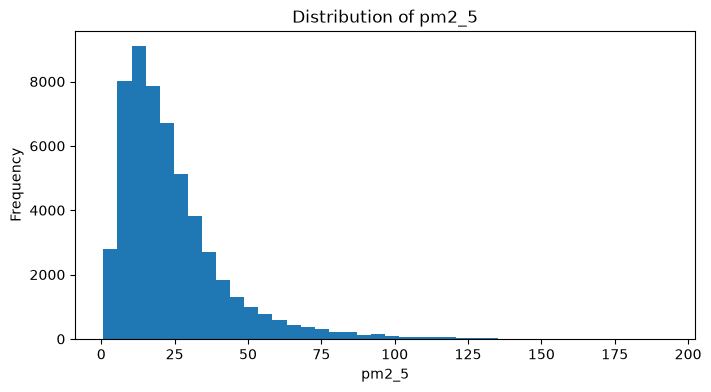

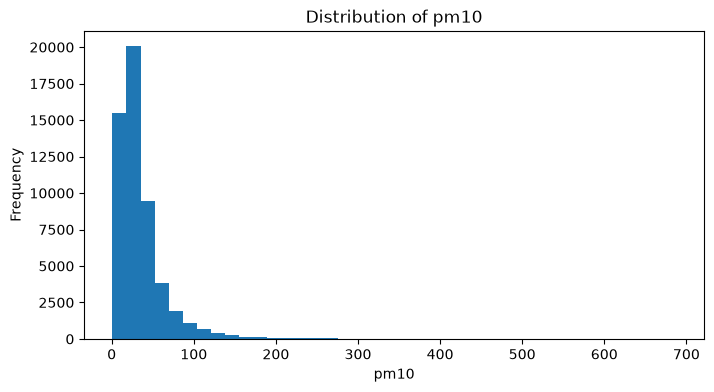

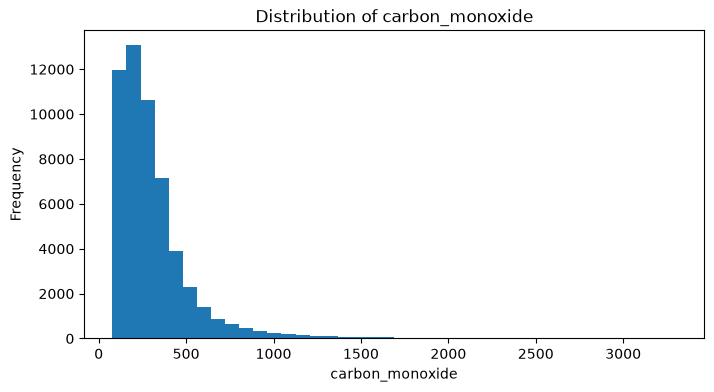

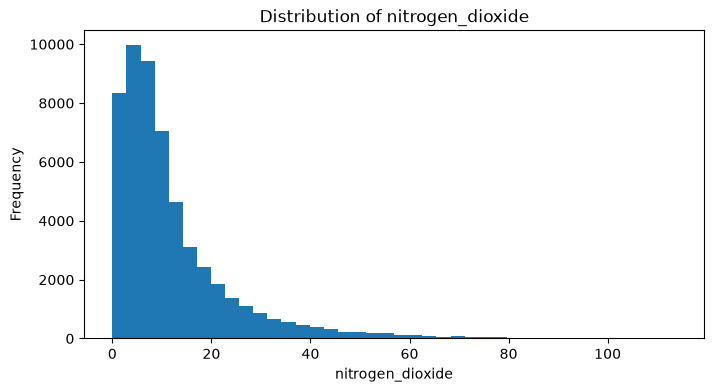

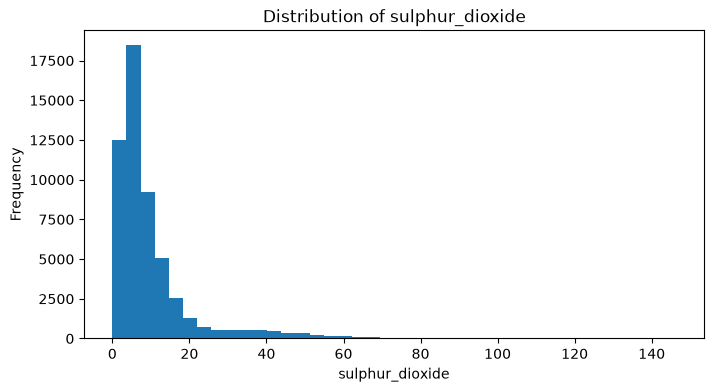

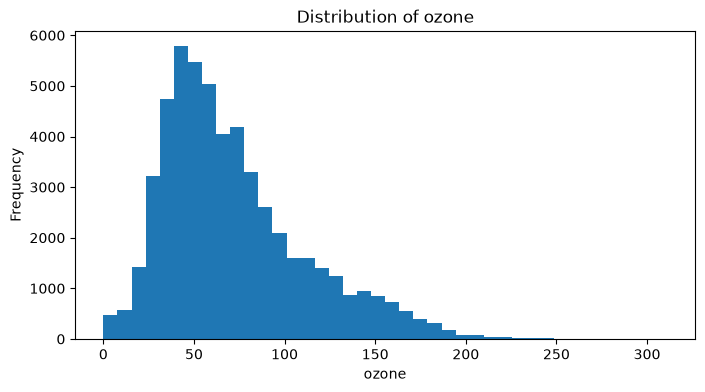

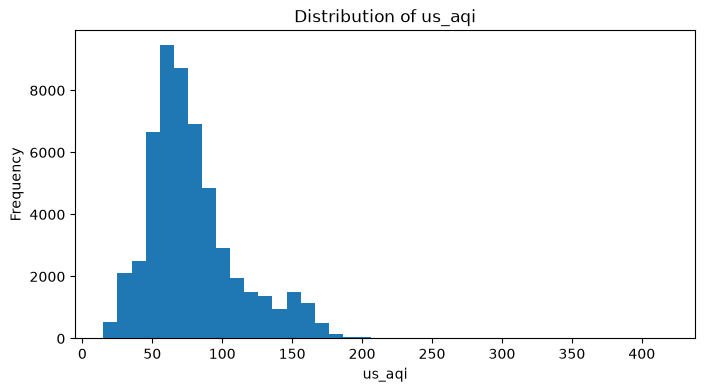

In [10]:

numeric_cols = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "us_aqi"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=40)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

Outlier Analysis

In [11]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percentage": count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,pm2_5,-16.25,58.55,2916,5.400000
1,pm10,-21.20,79.60,3814,7.062963
2,carbon_monoxide,-136.00,672.00,3254,6.025926
3,nitrogen_dioxide,-11.90,31.30,3796,7.029630
4,sulphur_dioxide,-7.15,22.05,4960,9.185185
5,ozone,-30.50,165.50,1608,2.977778
6,us_aqi,3.00,147.00,3408,6.311111


Outlier Analysis:
IQR-based analysis was used to identify statistically extreme observations in pollutant concentrations and US AQI. Outlier percentages ranged from 2.98% for ozone to 9.19% for sulphur dioxide. These observations were retained because extreme pollution values may represent genuine environmental events rather than data errors. Further investigation was performed using city, time, and pollutant-level analysis.

In [12]:
# ==========================================
# City-Level AQI Summary
# ==========================================

city_aqi = (
    df
    .groupby(["city", "state"])["us_aqi"]
    .agg(
        avg_aqi="mean",
        min_aqi="min",
        max_aqi="max",
        observations="count"
    )
    .reset_index()
)

# Round average AQI
city_aqi["avg_aqi"] = city_aqi["avg_aqi"].round(2)

# Sort from highest to lowest average AQI
city_aqi = city_aqi.sort_values(
    "avg_aqi",
    ascending=False
).reset_index(drop=True)

display(city_aqi.head(10))

,city,state,avg_aqi,min_aqi,max_aqi,observations
0,Delhi,Delhi,154.12,70,418,1080
1,Amritsar,Punjab,146.98,82,203,1080
2,Ludhiana,Punjab,146.76,77,183,1080
3,Meerut,Uttar Pradesh,139.81,63,354,1080
4,Chandigarh,Chandigarh,136.33,81,203,1080
5,Jammu,Jammu and Kashmir,126.73,77,170,1080
6,Srinagar,Jammu and Kashmir,104.25,64,161,1080
7,Jaipur,Rajasthan,98.30,55,153,1080
8,Patna,Bihar,97.52,51,185,1080
9,Agra,Uttar Pradesh,96.94,61,164,1080


In [13]:
# Top 10 cities by average AQI

top_10_cities = city_aqi.head(10)

display(top_10_cities)

,city,state,avg_aqi,min_aqi,max_aqi,observations
0,Delhi,Delhi,154.12,70,418,1080
1,Amritsar,Punjab,146.98,82,203,1080
2,Ludhiana,Punjab,146.76,77,183,1080
3,Meerut,Uttar Pradesh,139.81,63,354,1080
4,Chandigarh,Chandigarh,136.33,81,203,1080
5,Jammu,Jammu and Kashmir,126.73,77,170,1080
6,Srinagar,Jammu and Kashmir,104.25,64,161,1080
7,Jaipur,Rajasthan,98.30,55,153,1080
8,Patna,Bihar,97.52,51,185,1080
9,Agra,Uttar Pradesh,96.94,61,164,1080


Delhi is the highest average observed us aql during the study period

In [14]:
# Bottom 10 cities by average AQI

bottom_10_cities = (
    city_aqi
    .sort_values("avg_aqi", ascending=True)
    .head(10)
)

display(bottom_10_cities)

,city,state,avg_aqi,min_aqi,max_aqi,observations
49,Mysuru,Karnataka,34.54,16,61,1080
48,Nashik,Maharashtra,36.79,18,55,1080
47,Pune,Maharashtra,37.91,19,67,1080
46,Coimbatore,Tamil Nadu,41.50,15,61,1080
45,Bengaluru,Karnataka,44.58,23,88,1080
44,Aurangabad,Maharashtra,46.04,18,63,1080
43,Thiruvananthapuram,Kerala,50.19,30,63,1080
42,Mangaluru,Karnataka,53.10,35,65,1080
41,Guwahati,Assam,55.73,36,103,1080
40,Kochi,Kerala,55.87,44,74,1080


In [15]:
# City with the highest recorded AQI

highest_aqi_city = (
    city_aqi
    .sort_values("max_aqi", ascending=False)
    .head(1)
)

display(highest_aqi_city)

,city,state,avg_aqi,min_aqi,max_aqi,observations
0,Delhi,Delhi,154.12,70,418,1080


In [16]:
# Top cities based on maximum AQI

extreme_aqi_cities = (
    city_aqi[
        ["city", "state", "avg_aqi", "max_aqi", "min_aqi"]
    ]
    .sort_values("max_aqi", ascending=False)
    .head(10)
)

display(extreme_aqi_cities)

,city,state,avg_aqi,max_aqi,min_aqi
0,Delhi,Delhi,154.12,418,70
3,Meerut,Uttar Pradesh,139.81,354,63
1,Amritsar,Punjab,146.98,203,82
4,Chandigarh,Chandigarh,136.33,203,81
8,Patna,Bihar,97.52,185,51
2,Ludhiana,Punjab,146.76,183,77
21,Kolkata,West Bengal,77.14,183,46
5,Jammu,Jammu and Kashmir,126.73,170,77
10,Lucknow,Uttar Pradesh,95.33,165,57
9,Agra,Uttar Pradesh,96.94,164,61


In [17]:
# City ranking based on average AQI

city_aqi["aqi_rank"] = (
    city_aqi["avg_aqi"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

display(city_aqi.head(10))

,city,state,avg_aqi,min_aqi,max_aqi,observations,aqi_rank
0,Delhi,Delhi,154.12,70,418,1080,1
1,Amritsar,Punjab,146.98,82,203,1080,2
2,Ludhiana,Punjab,146.76,77,183,1080,3
3,Meerut,Uttar Pradesh,139.81,63,354,1080,4
4,Chandigarh,Chandigarh,136.33,81,203,1080,5
5,Jammu,Jammu and Kashmir,126.73,77,170,1080,6
6,Srinagar,Jammu and Kashmir,104.25,64,161,1080,7
7,Jaipur,Rajasthan,98.30,55,153,1080,8
8,Patna,Bihar,97.52,51,185,1080,9
9,Agra,Uttar Pradesh,96.94,61,164,1080,10


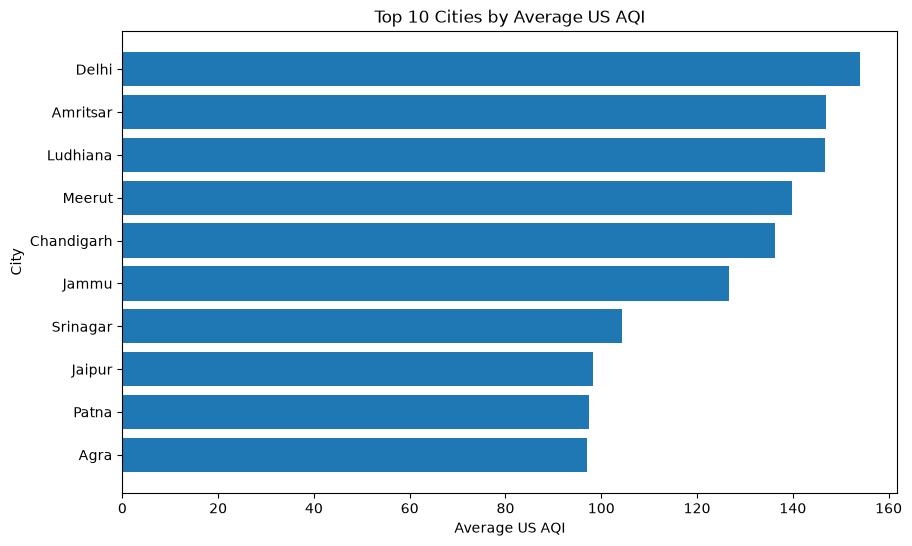

In [18]:
##Visualization

##Once the calculations work, create the top-10 chart:

import matplotlib.pyplot as plt

top_10 = (
    city_aqi
    .head(10)
    .sort_values("avg_aqi", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["city"],
    top_10["avg_aqi"]
)

plt.xlabel("Average US AQI")
plt.ylabel("City")
plt.title("Top 10 Cities by Average US AQI")

plt.show()

In [19]:
city_counts = (
    df.groupby("city")
      .size()
      .reset_index(name="observations")
      .sort_values("observations")
)

display(city_counts)

,city,observations
0,Agra,1080
1,Ahmedabad,1080
2,Amritsar,1080
3,Aurangabad,1080
4,Bengaluru,1080
5,Bhopal,1080
6,Bhubaneswar,1080
7,Chandigarh,1080
8,Chennai,1080
9,Coimbatore,1080


In [20]:
city_aqi = (
    df.groupby(["city", "state"])["us_aqi"]
      .agg(
          avg_aqi="mean",
          min_aqi="min",
          max_aqi="max",
          observations="count"
      )
      .reset_index()
)

city_aqi["avg_aqi"] = city_aqi["avg_aqi"].round(2)

city_aqi = city_aqi.sort_values(
    "avg_aqi",
    ascending=False
).reset_index(drop=True)

display(city_aqi.head(10))

,city,state,avg_aqi,min_aqi,max_aqi,observations
0,Delhi,Delhi,154.12,70,418,1080
1,Amritsar,Punjab,146.98,82,203,1080
2,Ludhiana,Punjab,146.76,77,183,1080
3,Meerut,Uttar Pradesh,139.81,63,354,1080
4,Chandigarh,Chandigarh,136.33,81,203,1080
5,Jammu,Jammu and Kashmir,126.73,77,170,1080
6,Srinagar,Jammu and Kashmir,104.25,64,161,1080
7,Jaipur,Rajasthan,98.30,55,153,1080
8,Patna,Bihar,97.52,51,185,1080
9,Agra,Uttar Pradesh,96.94,61,164,1080


In [21]:
bottom_10_cities = (
    city_aqi
    .sort_values("avg_aqi", ascending=True)
    .head(10)
)

display(bottom_10_cities)

,city,state,avg_aqi,min_aqi,max_aqi,observations
49,Mysuru,Karnataka,34.54,16,61,1080
48,Nashik,Maharashtra,36.79,18,55,1080
47,Pune,Maharashtra,37.91,19,67,1080
46,Coimbatore,Tamil Nadu,41.50,15,61,1080
45,Bengaluru,Karnataka,44.58,23,88,1080
44,Aurangabad,Maharashtra,46.04,18,63,1080
43,Thiruvananthapuram,Kerala,50.19,30,63,1080
42,Mangaluru,Karnataka,53.10,35,65,1080
41,Guwahati,Assam,55.73,36,103,1080
40,Kochi,Kerala,55.87,44,74,1080


            state level anaklysis

In [22]:
# ==========================================
# STATE-LEVEL AQI ANALYSIS
# ==========================================

state_aqi = (
    df
    .groupby("state")["us_aqi"]
    .agg(
        avg_aqi="mean",
        min_aqi="min",
        max_aqi="max",
        observations="count",
        cities="nunique"
    )
    .reset_index()
)

state_aqi["avg_aqi"] = state_aqi["avg_aqi"].round(2)

state_aqi = state_aqi.sort_values(
    "avg_aqi",
    ascending=False
).reset_index(drop=True)

display(state_aqi)

,state,avg_aqi,min_aqi,max_aqi,observations,cities
0,Delhi,154.12,70,418,1080,196
1,Punjab,146.87,77,203,2160,116
2,Chandigarh,136.33,81,203,1080,120
3,Jammu and Kashmir,115.49,64,170,2160,104
4,Uttar Pradesh,100.19,53,354,6480,196
5,Bihar,90.60,51,185,2160,124
6,Chhattisgarh,86.45,54,123,1080,70
7,Andhra Pradesh,83.17,55,157,2160,98
8,Rajasthan,83.02,46,153,4320,107
9,Uttarakhand,81.73,54,162,1080,97


In [23]:
# Top states by average AQI

top_states = (
    state_aqi
    .sort_values("avg_aqi", ascending=False)
    .head(10)
)

display(top_states)

,state,avg_aqi,min_aqi,max_aqi,observations,cities
0,Delhi,154.12,70,418,1080,196
1,Punjab,146.87,77,203,2160,116
2,Chandigarh,136.33,81,203,1080,120
3,Jammu and Kashmir,115.49,64,170,2160,104
4,Uttar Pradesh,100.19,53,354,6480,196
5,Bihar,90.60,51,185,2160,124
6,Chhattisgarh,86.45,54,123,1080,70
7,Andhra Pradesh,83.17,55,157,2160,98
8,Rajasthan,83.02,46,153,4320,107
9,Uttarakhand,81.73,54,162,1080,97


In [24]:
# Bottom states by average AQI

bottom_states = (
    state_aqi
    .sort_values("avg_aqi", ascending=True)
    .head(10)
)

display(bottom_states)

,state,avg_aqi,min_aqi,max_aqi,observations,cities
21,Karnataka,44.07,16,88,3240,69
20,Maharashtra,49.96,18,99,5400,82
19,Kerala,53.03,30,74,2160,42
18,Assam,55.73,36,103,1080,59
17,Tamil Nadu,58.24,15,147,3240,113
16,Telangana,59.09,31,85,1080,54
15,Jharkhand,67.13,32,146,1080,81
14,Madhya Pradesh,67.88,35,106,3240,72
13,Gujarat,69.04,40,109,4320,70
12,Odisha,76.50,40,140,3240,90


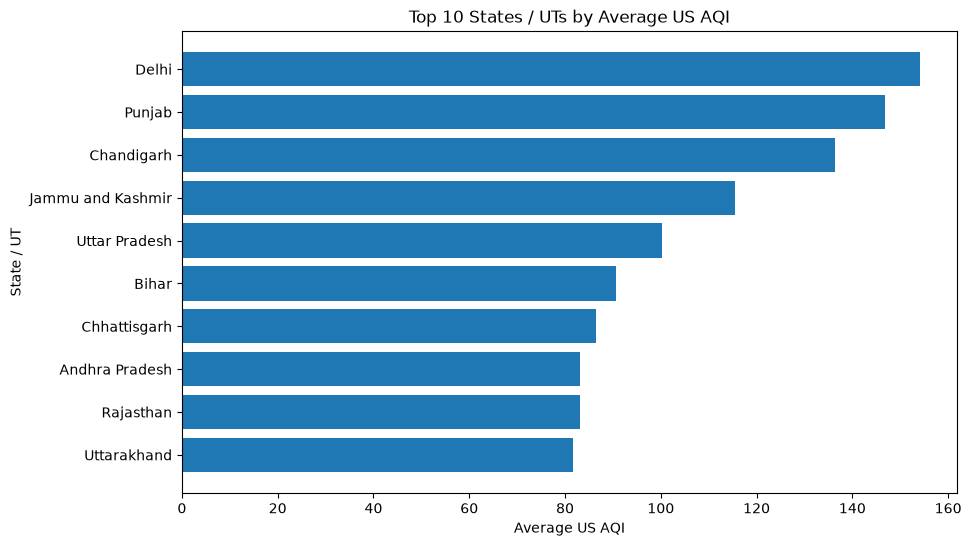

In [25]:
###State-level visualization
import matplotlib.pyplot as plt

top_states_plot = (
    state_aqi
    .head(10)
    .sort_values("avg_aqi", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states_plot["state"],
    top_states_plot["avg_aqi"]
)

plt.xlabel("Average US AQI")
plt.ylabel("State / UT")
plt.title("Top 10 States / UTs by Average US AQI")

plt.show()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              54000 non-null  str    
 1   pm2_5             54000 non-null  float64
 2   pm10              54000 non-null  float64
 3   carbon_monoxide   54000 non-null  float64
 4   nitrogen_dioxide  54000 non-null  float64
 5   sulphur_dioxide   54000 non-null  float64
 6   ozone             54000 non-null  float64
 7   us_aqi            54000 non-null  int64  
 8   city              54000 non-null  str    
 9   state             54000 non-null  str    
 10  latitude          54000 non-null  float64
 11  longitude         54000 non-null  float64
 12  date              54000 non-null  str    
 13  year              54000 non-null  int64  
 14  month             54000 non-null  int64  
 15  day               54000 non-null  int64  
 16  hour              54000 non-null  int64  
 17  day_

                 Pollutant Analisys

=== 1. State-Level Mean Concentrations & Sample Sizes ===
                   pm2_5    pm10  carbon_monoxide  nitrogen_dioxide  \
state                                                                 
Punjab             60.62   80.15           624.19             22.66   
Delhi              60.06  119.15           791.54             35.96   
Chandigarh         49.26   61.19           671.02             23.02   
Jammu and Kashmir  40.34   47.71           616.15             20.97   
Uttar Pradesh      33.79   45.47           399.65             14.67   
Chhattisgarh       28.41   34.18           355.29             25.47   
Bihar              27.87   28.65           327.59             11.44   
Andhra Pradesh     26.16   35.20           332.93             17.11   
Rajasthan          25.81   62.53           203.26              7.78   
Odisha             22.56   25.92           326.76             10.24   
West Bengal        22.52   24.83           409.65             10.16   
Uttarakhand        

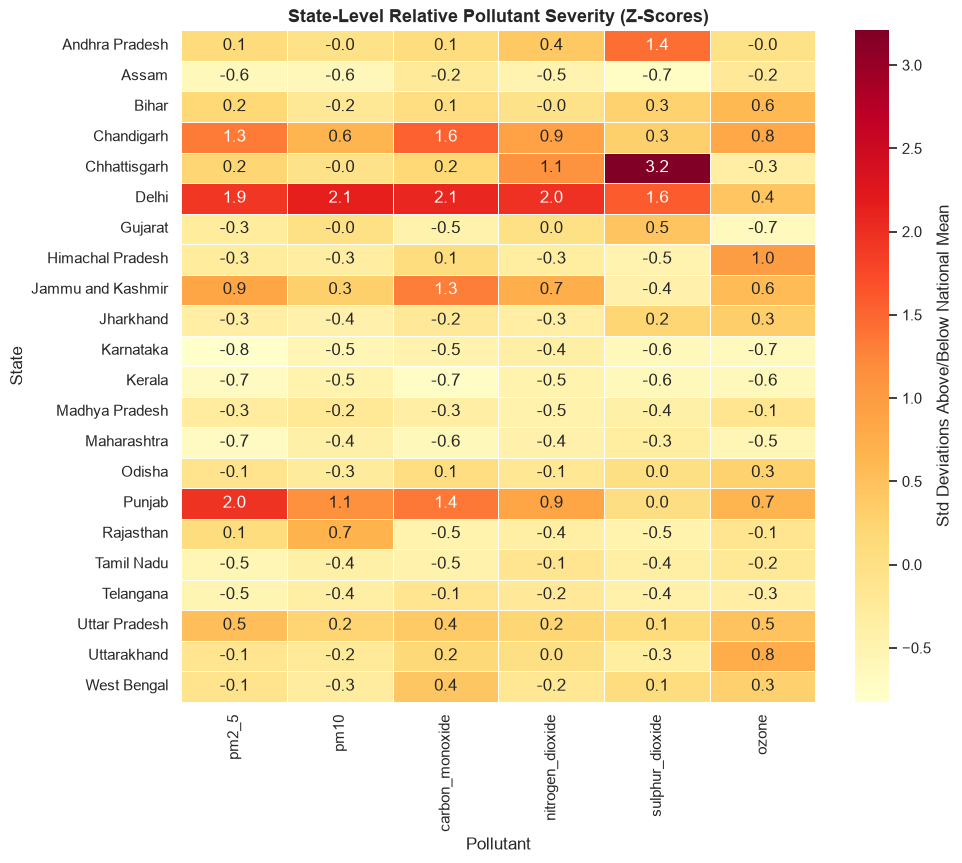

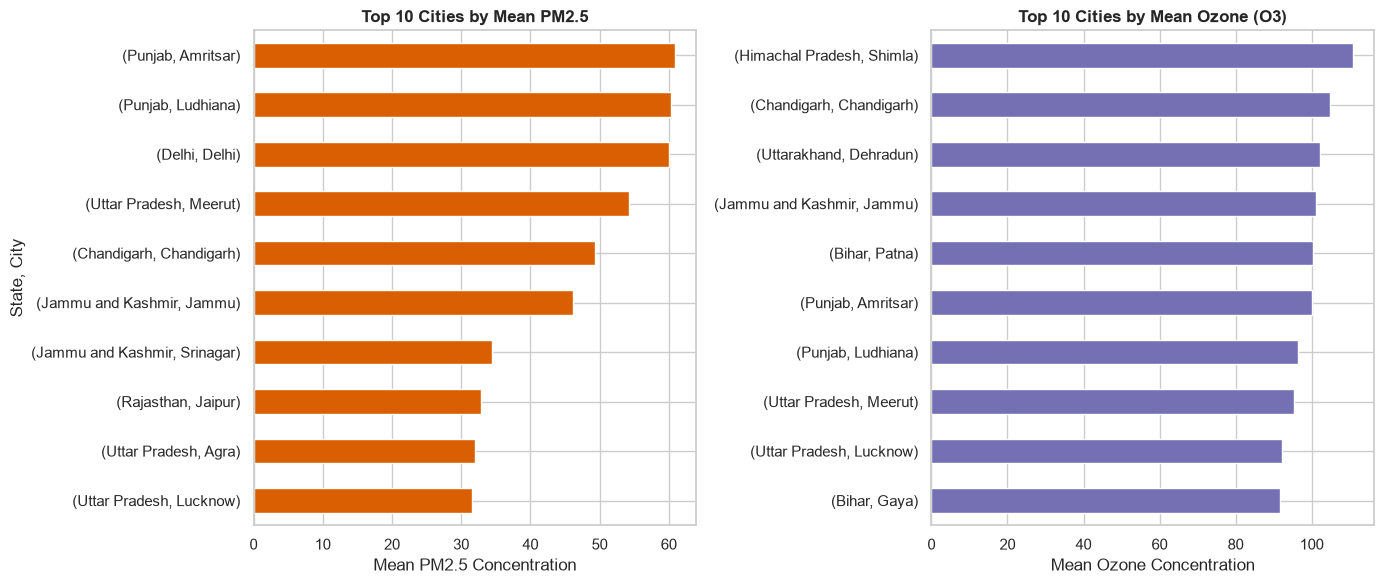

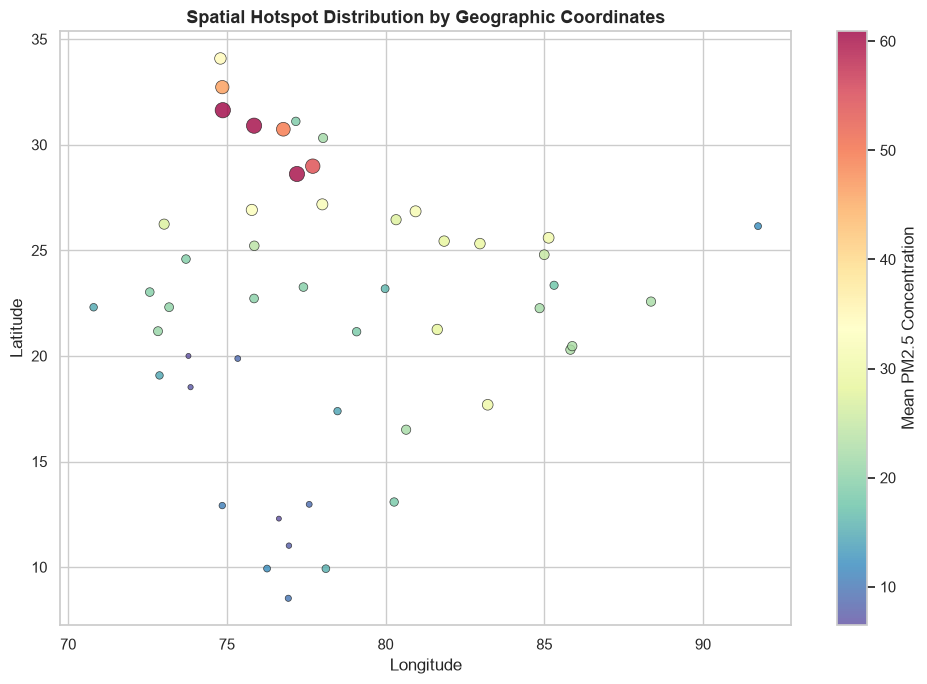

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

POLLUTANTS = [
    'pm2_5',
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
]

# ==============================================================================
# 1. STATE-LEVEL POLLUTANT SUMMARY
# ==============================================================================
print('=== 1. State-Level Mean Concentrations & Sample Sizes ===')
state_summary = (
    df.groupby('state')[POLLUTANTS]
    .agg(['mean', 'max'])
    .round(2)
)
# Rank states by overall PM2.5 burden
state_mean = df.groupby('state')[POLLUTANTS].mean().round(2)
print(state_mean.sort_values(by='pm2_5', ascending=False))

# Identify which pollutant is highest relative to national average per state
z_scores_by_state = (state_mean - df[POLLUTANTS].mean()) / df[POLLUTANTS].std()
state_dominant_pollutant = z_scores_by_state.idxmax(axis=1)
print('\n=== Predominant Excess Pollutant by State ===')
print(state_dominant_pollutant.to_frame(name='Highest Relative Driver'))

# ==============================================================================
# 2. CITY-LEVEL HOTSPOTS & RANKINGS
# ==============================================================================
print('\n=== 2. Top 5 Most Polluted Cities by Pollutant ===')
city_stats = (
    df.groupby(['state', 'city'])[POLLUTANTS]
    .mean()
    .round(2)
)

for pol in POLLUTANTS:
  top5 = (
      city_stats[pol]
      .sort_values(ascending=False)
      .head(5)
      .reset_index()
  )
  print(f'\nTop 5 for {pol.upper()}:')
  print(top5.to_string(index=False))

# ==============================================================================
# 3. INTRA-STATE DISPARITY (CITY-TO-CITY VARIATION)
# ==============================================================================
# Evaluates whether pollution is statewide or concentrated in specific urban clusters
print('\n=== 3. Intra-State Disparity (Coefficient of Variation: PM2.5) ===')
state_disparity = (
    df.groupby('state')
    .apply(
        lambda x: (
            x.groupby('city')['pm2_5'].mean().std()
            / x.groupby('city')['pm2_5'].mean().mean()
        )
        * 100
        if x['city'].nunique() > 1
        else np.nan,
        include_groups=False,
    )
    .dropna()
    .sort_values(ascending=False)
    .round(2)
)
print(state_disparity.to_frame(name='PM2.5 Inter-City CV (%)'))

# ==============================================================================
# 4. COMPOSITE REGIONAL BURDEN INDEX
# ==============================================================================
# Min-Max normalize each pollutant to [0, 1] across all cities to score cumulative multi-pollutant burden
city_norm = (city_stats - city_stats.min()) / (
    city_stats.max() - city_stats.min()
)
city_composite_score = (
    city_norm.mean(axis=1).sort_values(ascending=False).round(3)
)

print('\n=== Top 10 Cities: Overall Cumulative Multi-Pollutant Burden ===')
print(
    city_composite_score.head(10).reset_index(
        name='Composite Normalized Index'
    )
)

# ==============================================================================
# 5. VISUALIZATIONS
# ==============================================================================
sns.set_theme(style='whitegrid')

# 5.1 State-Level Pollutant Profiles (Heatmap of Standardized Scores)
plt.figure(figsize=(10, max(6, len(state_mean) * 0.4)))
sns.heatmap(
    z_scores_by_state,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Std Deviations Above/Below National Mean'},
)
plt.title(
    'State-Level Relative Pollutant Severity (Z-Scores)',
    fontsize=13,
    weight='bold',
)
plt.xlabel('Pollutant')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# 5.2 Top 10 Cities for PM2.5 vs Ozone
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_pm25 = city_stats['pm2_5'].nlargest(10).sort_values()
top10_o3 = city_stats['ozone'].nlargest(10).sort_values()

# PM2.5 plot
top10_pm25.plot(kind='barh', ax=axes[0], color='#d95f02')
axes[0].set_title('Top 10 Cities by Mean PM2.5', weight='bold')
axes[0].set_xlabel('Mean PM2.5 Concentration')
axes[0].set_ylabel('State, City')

# Ozone plot
top10_o3.plot(kind='barh', ax=axes[1], color='#7570b3')
axes[1].set_title('Top 10 Cities by Mean Ozone (O3)', weight='bold')
axes[1].set_xlabel('Mean Ozone Concentration')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 5.3 Geographic Scatter Plot (Coordinates & Particulate Load)
if 'latitude' in df.columns and 'longitude' in df.columns:
  city_geo = (
      df.groupby(['city', 'state'])
      .agg({'latitude': 'first', 'longitude': 'first', 'pm2_5': 'mean'})
      .reset_index()
  )

  plt.figure(figsize=(10, 7))
  scatter = plt.scatter(
      city_geo['longitude'],
      city_geo['latitude'],
      c=city_geo['pm2_5'],
      cmap='Spectral_r',
      s=city_geo['pm2_5'] * 2,
      alpha=0.8,
      edgecolors='k',
      linewidth=0.5,
  )
  cbar = plt.colorbar(scatter)
  cbar.set_label('Mean PM2.5 Concentration')
  plt.title(
      'Spatial Hotspot Distribution by Geographic Coordinates',
      fontsize=13,
      weight='bold',
  )
  plt.xlabel('Longitude')
  plt.ylabel('Latitude')
  plt.tight_layout()
  plt.show()

In [28]:
# ============================================
# FEATURE ENGINEERING FOR ML
# ============================================

import numpy as np

# Weekend flag
df["is_weekend"] = (
    df["day_of_week"].isin([5, 6])
).astype(int)

# Peak-hour flag
df["is_peak_hour"] = (
    df["hour"].isin([8, 9, 17, 18, 19])
).astype(int)

# PM2.5 / PM10 ratio
df["pm25_pm10_ratio"] = (
    df["pm2_5"] / df["pm10"]
)

# Replace infinity values
df["pm25_pm10_ratio"] = (
    df["pm25_pm10_ratio"]
    .replace([np.inf, -np.inf], np.nan)
)

# Cyclical encoding of hour
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Cyclical encoding of day of week
df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

print("Feature engineering completed.")

Feature engineering completed.


In [29]:
# Check newly created features

new_features = [
    "is_weekend",
    "is_peak_hour",
    "pm25_pm10_ratio",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

display(df[new_features].head(10))

print("\nMissing values:")
display(df[new_features].isnull().sum())

,is_weekend,is_peak_hour,pm25_pm10_ratio,hour_sin,hour_cos,dow_sin,dow_cos
0,1,0,0.969492,0.000000,1.000000e+00,-0.974928,-0.222521
1,1,0,0.260925,0.258819,9.659258e-01,-0.974928,-0.222521
2,1,0,0.218778,0.500000,8.660254e-01,-0.974928,-0.222521
3,1,0,0.209588,0.707107,7.071068e-01,-0.974928,-0.222521
4,1,0,0.215549,0.866025,5.000000e-01,-0.974928,-0.222521
5,1,0,0.962264,0.965926,2.588190e-01,-0.974928,-0.222521
6,1,0,0.964029,1.000000,6.123234e-17,-0.974928,-0.222521
7,1,0,0.961538,0.965926,-2.588190e-01,-0.974928,-0.222521
8,1,1,0.963504,0.866025,-5.000000e-01,-0.974928,-0.222521
9,1,1,0.973077,0.707107,-7.071068e-01,-0.974928,-0.222521



Missing values:


is_weekend         0
is_peak_hour       0
pm25_pm10_ratio    0
hour_sin           0
hour_cos           0
dow_sin            0
dow_cos            0
dtype: int64

In [30]:
print("df shape:", df.shape)
print("\nNew columns:")
print(new_features)

df shape: (54000, 29)

New columns:
['is_weekend', 'is_peak_hour', 'pm25_pm10_ratio', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [31]:
# ============================================
# STEP 1: PREPARE DATA FOR MACHINE LEARNING
# ============================================


# Make sure time is datetime
df["time"] = pd.to_datetime(df["time"])

# Sort data correctly
df = df.sort_values(["city", "time"]).reset_index(drop=True)

# Create target: Next hour AQI
df["next_hour_aqi"] = (
    df.groupby("city")["us_aqi"]
      .shift(-1)
)

# Check
display(df[["city", "time", "us_aqi", "next_hour_aqi"]].head(10))

,city,time,us_aqi,next_hour_aqi
0,Agra,2026-08-01 00:00:00,78,79.0
1,Agra,2026-08-01 01:00:00,79,79.0
2,Agra,2026-08-01 02:00:00,79,79.0
3,Agra,2026-08-01 03:00:00,79,79.0
4,Agra,2026-08-01 04:00:00,79,80.0
5,Agra,2026-08-01 05:00:00,80,80.0
6,Agra,2026-08-01 06:00:00,80,81.0
7,Agra,2026-08-01 07:00:00,81,81.0
8,Agra,2026-08-01 08:00:00,81,81.0
9,Agra,2026-08-01 09:00:00,81,81.0


In [32]:
# ============================================
# STEP 3: CREATE ML DATASET
# ============================================

features = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "hour",
    "day_of_week",
    "month",
    "latitude",
    "longitude",
    "is_weekend",
    "is_peak_hour",
    "pm25_pm10_ratio",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

target = "next_hour_aqi"

ml_df = df[features + [target]].copy()

# Remove rows where target is missing
ml_df = ml_df.dropna()

print("ML dataset shape:", ml_df.shape)

display(ml_df.head())

ML dataset shape: (53950, 19)


,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,hour,day_of_week,month,latitude,longitude,is_weekend,is_peak_hour,pm25_pm10_ratio,hour_sin,hour_cos,dow_sin,dow_cos,next_hour_aqi
0,28.2,28.9,286.0,11.5,9.2,87.0,0,5,8,27.1767,78.0081,1,0,0.975779,0.000000,1.000000,-0.974928,-0.222521,79.0
1,27.2,27.6,279.0,10.7,9.1,86.0,1,5,8,27.1767,78.0081,1,0,0.985507,0.258819,0.965926,-0.974928,-0.222521,79.0
2,26.8,27.2,275.0,10.1,9.2,85.0,2,5,8,27.1767,78.0081,1,0,0.985294,0.500000,0.866025,-0.974928,-0.222521,79.0
3,26.8,31.5,276.0,10.0,9.8,83.0,3,5,8,27.1767,78.0081,1,0,0.850794,0.707107,0.707107,-0.974928,-0.222521,79.0
4,28.1,45.6,280.0,10.1,10.7,80.0,4,5,8,27.1767,78.0081,1,0,0.616228,0.866025,0.500000,-0.974928,-0.222521,80.0


In [33]:
# ============================================
# CREATE TARGET
# ============================================

df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(
    ["city", "time"]
).reset_index(drop=True)

df["next_hour_aqi"] = (
    df.groupby("city")["us_aqi"]
      .shift(-1)
)

print("Target created successfully.")

display(
    df[[
        "city",
        "time",
        "us_aqi",
        "next_hour_aqi"
    ]].head(10)
)

Target created successfully.


,city,time,us_aqi,next_hour_aqi
0,Agra,2026-08-01 00:00:00,78,79.0
1,Agra,2026-08-01 01:00:00,79,79.0
2,Agra,2026-08-01 02:00:00,79,79.0
3,Agra,2026-08-01 03:00:00,79,79.0
4,Agra,2026-08-01 04:00:00,79,80.0
5,Agra,2026-08-01 05:00:00,80,80.0
6,Agra,2026-08-01 06:00:00,80,81.0
7,Agra,2026-08-01 07:00:00,81,81.0
8,Agra,2026-08-01 08:00:00,81,81.0
9,Agra,2026-08-01 09:00:00,81,81.0


In [34]:
# ============================================
# STEP 4: TIME-BASED TRAIN / TEST SPLIT
# ============================================

# Create model dataset
model_df = df[
    ["time"] + features + [target]
].copy()

# Remove rows with missing values
model_df = model_df.dropna()

# Sort chronologically
model_df = model_df.sort_values("time").reset_index(drop=True)

# 80% training, 20% testing
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Total rows   :", len(model_df))
print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

print("\nTraining period:")
print(train_df["time"].min(), "→", train_df["time"].max())

print("\nTesting period:")
print(test_df["time"].min(), "→", test_df["time"].max())

Total rows   : 53950
Training rows: 43160
Testing rows : 10790

Training period:
2026-08-01 00:00:00 → 2026-09-05 23:00:00

Testing period:
2026-09-05 23:00:00 → 2026-09-14 22:00:00


In [35]:
# ============================================
# TRAIN / TEST SIZE CHECK
# ============================================

print("Train percentage:",
      round(len(train_df) / len(model_df) * 100, 2), "%")

print("Test percentage:",
      round(len(test_df) / len(model_df) * 100, 2), "%")

Train percentage: 80.0 %
Test percentage: 20.0 %


In [36]:
# ============================================
# STEP 5: CREATE X AND y
# ============================================

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (43160, 18)
y_train: (43160,)
X_test : (10790, 18)
y_test : (10790,)


In [37]:
##Verify missing values
print("Missing values in X_train:",
      X_train.isnull().sum().sum())

print("Missing values in X_test:",
      X_test.isnull().sum().sum())

print("Missing values in y_train:",
      y_train.isnull().sum())

print("Missing values in y_test:",
      y_test.isnull().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [38]:
# ============================================
# STEP 6: BASELINE MODEL
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Mean AQI from training data
baseline_value = y_train.mean()

# Predict same value for every test observation
baseline_pred = np.full(
    len(y_test),
    baseline_value
)

print("Baseline predicted AQI:",
      round(baseline_value, 2))

Baseline predicted AQI: 78.85


In [39]:
##Evaluate:

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²  :", round(baseline_r2, 4))

Baseline MAE : 23.59
Baseline RMSE: 31.73
Baseline R²  : -0.0114


In [40]:
# ============================================
# STEP 7: LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

print("Linear Regression training completed.")

Linear Regression training completed.


In [41]:
##Evaluate:

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression")
print("------------------")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R²  :", round(lr_r2, 4))

Linear Regression
------------------
MAE : 11.33
RMSE: 15.16
R²  : 0.7693


In [42]:
# ============================================
# STEP 8: DECISION TREE
# ============================================

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [43]:
###Evaluate:

dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree")
print("-------------")
print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R²  :", round(dt_r2, 4))

Decision Tree
-------------
MAE : 11.12
RMSE: 16.05
R²  : 0.7413


In [44]:
# ============================================
# STEP 9: RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [45]:
##Evaluate:

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------
MAE : 9.86
RMSE: 14.0
R²  : 0.803


In [46]:
# ============================================
# STEP 10: MODEL COMPARISON
# ============================================

results = pd.DataFrame([
    {
        "Model": "Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Linear Regression",
        "MAE": lr_mae,
        "RMSE": lr_rmse,
        "R2": lr_r2
    },
    {
        "Model": "Decision Tree",
        "MAE": dt_mae,
        "RMSE": dt_rmse,
        "R2": dt_r2
    },
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    }
])

results["MAE"] = results["MAE"].round(2)
results["RMSE"] = results["RMSE"].round(2)
results["R2"] = results["R2"].round(4)

display(
    results.sort_values("RMSE")
)

,Model,MAE,RMSE,R2
3,Random Forest,9.86,14.00,0.8030
1,Linear Regression,11.33,15.16,0.7693
2,Decision Tree,11.12,16.05,0.7413
0,Baseline,23.59,31.73,-0.0114


In [47]:
# ============================================
# STEP 11: HYPERPARAMETER TUNING
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [48]:
# Random Forest model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0]
}

In [49]:
# ============================================
# RANDOMIZED SEARCH
# ============================================

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter tuning completed.


In [50]:
# ============================================
# BEST PARAMETERS
# ============================================

print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest Cross-Validation RMSE:")
print(round(-rf_random.best_score_, 2))

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}

Best Cross-Validation RMSE:
14.72


In [51]:
# ============================================
# FINAL TUNED MODEL
# ============================================

best_rf = rf_random.best_estimator_

print(best_rf)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=5, n_estimators=300, n_jobs=-1,
                      random_state=42)


In [52]:
# ============================================
# FINAL PREDICTIONS
# ============================================

final_pred = best_rf.predict(X_test)

print("Predictions generated:", len(final_pred))

Predictions generated: 10790


In [53]:
# ============================================
# FINAL MODEL EVALUATION
# ============================================

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("Final Tuned Random Forest")
print("=========================")
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 4))

Final Tuned Random Forest
MAE : 9.35
RMSE: 13.17
R²  : 0.8257


In [54]:
# ============================================
# BEFORE VS AFTER TUNING
# ============================================

before_after = pd.DataFrame([
    {
        "Model": "Random Forest - Before Tuning",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    },
    {
        "Model": "Random Forest - After Tuning",
        "MAE": final_mae,
        "RMSE": final_rmse,
        "R2": final_r2
    }
])

before_after["MAE"] = before_after["MAE"].round(2)
before_after["RMSE"] = before_after["RMSE"].round(2)
before_after["R2"] = before_after["R2"].round(4)

display(before_after)

,Model,MAE,RMSE,R2
0,Random Forest - Before Tuning,9.86,14.00,0.8030
1,Random Forest - After Tuning,9.35,13.17,0.8257


In [55]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": best_rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance)

,feature,importance
0,pm2_5,0.291883
1,latitude,0.210311
2,pm10,0.156536
3,carbon_monoxide,0.063421
4,ozone,0.057804
5,sulphur_dioxide,0.054480
6,longitude,0.051258
7,pm25_pm10_ratio,0.038093
8,nitrogen_dioxide,0.025605
9,hour,0.009390


In [56]:
display(
    feature_importance.head(10)
)

,feature,importance
0,pm2_5,0.291883
1,latitude,0.210311
2,pm10,0.156536
3,carbon_monoxide,0.063421
4,ozone,0.057804
5,sulphur_dioxide,0.054480
6,longitude,0.051258
7,pm25_pm10_ratio,0.038093
8,nitrogen_dioxide,0.025605
9,hour,0.009390


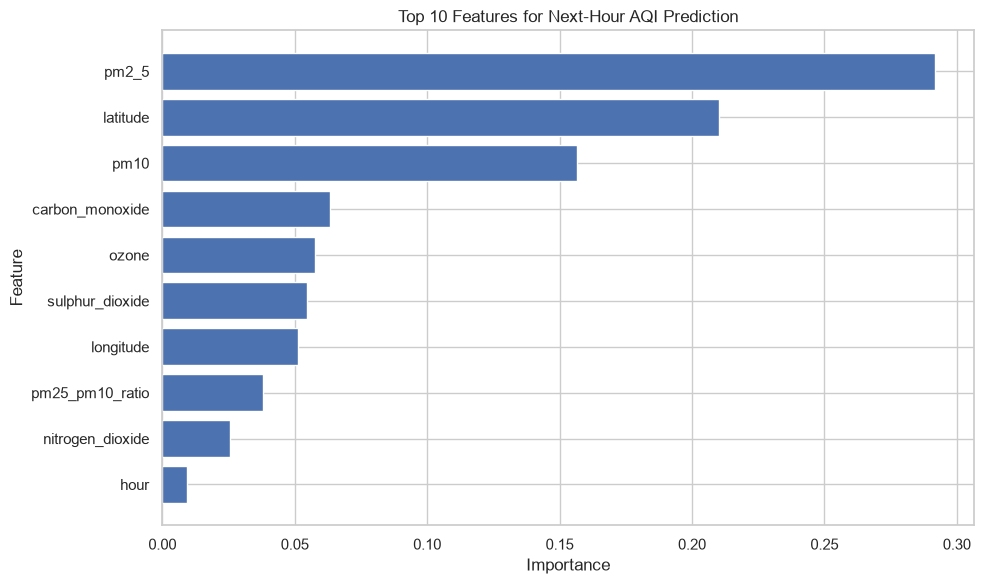

In [57]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Next-Hour AQI Prediction")

plt.tight_layout()
plt.show()

In [58]:
# ============================================
# FINAL PREDICTION DATASET
# ============================================

prediction_df = test_df[
    ["time", "next_hour_aqi"]
].copy()

prediction_df["predicted_aqi"] = final_pred

prediction_df["prediction_error"] = (
    prediction_df["next_hour_aqi"]
    - prediction_df["predicted_aqi"]
)

prediction_df["absolute_error"] = (
    prediction_df["prediction_error"]
    .abs()
)

display(
    prediction_df.head(20)
)

,time,next_hour_aqi,predicted_aqi,prediction_error,absolute_error
43160,2026-09-05 23:00:00,67.0,66.666034,0.333966,0.333966
43161,2026-09-05 23:00:00,58.0,61.548969,-3.548969,3.548969
43162,2026-09-05 23:00:00,49.0,49.230465,-0.230465,0.230465
43163,2026-09-05 23:00:00,133.0,135.388995,-2.388995,2.388995
43164,2026-09-05 23:00:00,59.0,61.874924,-2.874924,2.874924
43165,2026-09-05 23:00:00,87.0,90.480588,-3.480588,3.480588
43166,2026-09-05 23:00:00,52.0,47.162089,4.837911,4.837911
43167,2026-09-05 23:00:00,122.0,124.013947,-2.013947,2.013947
43168,2026-09-05 23:00:00,87.0,88.699256,-1.699256,1.699256
43169,2026-09-05 23:00:00,38.0,37.273528,0.726472,0.726472


In [59]:
# ============================================
# ACTUAL VS PREDICTED SUMMARY
# ============================================

comparison = prediction_df[
    [
        "time",
        "next_hour_aqi",
        "predicted_aqi",
        "absolute_error"
    ]
].copy()

comparison["predicted_aqi"] = (
    comparison["predicted_aqi"]
    .round(2)
)

comparison["absolute_error"] = (
    comparison["absolute_error"]
    .round(2)
)

display(comparison.head(20))

,time,next_hour_aqi,predicted_aqi,absolute_error
43160,2026-09-05 23:00:00,67.0,66.67,0.33
43161,2026-09-05 23:00:00,58.0,61.55,3.55
43162,2026-09-05 23:00:00,49.0,49.23,0.23
43163,2026-09-05 23:00:00,133.0,135.39,2.39
43164,2026-09-05 23:00:00,59.0,61.87,2.87
43165,2026-09-05 23:00:00,87.0,90.48,3.48
43166,2026-09-05 23:00:00,52.0,47.16,4.84
43167,2026-09-05 23:00:00,122.0,124.01,2.01
43168,2026-09-05 23:00:00,87.0,88.70,1.70
43169,2026-09-05 23:00:00,38.0,37.27,0.73


In [60]:
# ============================================
# SAVE ML OUTPUTS
# ============================================

results.to_csv(
    "aqi_model_comparison.csv",
    index=False
)

before_after.to_csv(
    "aqi_rf_tuning_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "aqi_feature_importance.csv",
    index=False
)

prediction_df.to_csv(
    "aqi_next_hour_predictions.csv",
    index=False
)

print("All ML outputs saved successfully.")

All ML outputs saved successfully.


# Conclusion

This project successfully developed an end-to-end **Indian Air Quality Analytics and Next-Hour AQI Prediction** solution using data from 50 selected Indian cities.

The project covered data collection through the Open-Meteo Air Quality API, data cleaning and validation, exploratory data analysis, outlier analysis, temporal and geographical analysis, feature engineering, SQL Server integration, and machine learning.

For machine learning, a **time-based 80/20 train-test split** was used to avoid future data leakage. Multiple regression models were evaluated, including Linear Regression, Decision Tree, and Random Forest. The Random Forest model performed best.

After hyperparameter tuning, the final Random Forest model achieved:

* **MAE:** 9.35 AQI points
* **RMSE:** 13.17 AQI points
* **R²:** 0.8257

The results show that the model can explain approximately **82.57% of the variation in next-hour US AQI** within the selected test period. **PM2.5** was the most important predictive feature, followed by latitude and PM10.

Overall, this project demonstrates an end-to-end data science workflow from **API data collection → Python/Pandas → SQL Server → EDA → Feature Engineering → Machine Learning → Prediction**, with the next step being integration of ML predictions into **Power BI for business-style reporting and visualization**.

**Note:** The analysis is based on 50 selected cities and the available August 1–September 14, 2026 observation period, so the model should not be considered a universal AQI forecasting model for all of India.


In [2]:
import pandas as pd

prediction_df = pd.read_csv("aqi_next_hour_predictions.csv")

print("Prediction DataFrame loaded successfully!")
print("Shape:", prediction_df.shape)

print("\nColumns:")
print(prediction_df.columns.tolist())

display(prediction_df.head())

Prediction DataFrame loaded successfully!
Shape: (10790, 5)

Columns:
['time', 'next_hour_aqi', 'predicted_aqi', 'prediction_error', 'absolute_error']


,time,next_hour_aqi,predicted_aqi,prediction_error,absolute_error
0,2026-09-05 23:00:00,67.0,66.666034,0.333966,0.333966
1,2026-09-05 23:00:00,58.0,61.548969,-3.548969,3.548969
2,2026-09-05 23:00:00,49.0,49.230465,-0.230465,0.230465
3,2026-09-05 23:00:00,133.0,135.388995,-2.388995,2.388995
4,2026-09-05 23:00:00,59.0,61.874924,-2.874924,2.874924


In [5]:
print(prediction_df.columns.tolist())
print(prediction_df.shape)

['time', 'next_hour_aqi', 'predicted_aqi', 'prediction_error', 'absolute_error']
(10790, 5)


In [2]:
from sqlalchemy import create_engine

server = r"LAPTOP-71G1NMQR\SQLEXPRESS"
database = "AQI_Analytics"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

print("SQL Server connection successful!")

SQL Server connection successful!


In [3]:
prediction_df.head()

,time,next_hour_aqi,predicted_aqi,prediction_error,absolute_error
0,2026-09-05 23:00:00,67.0,66.666034,0.333966,0.333966
1,2026-09-05 23:00:00,58.0,61.548969,-3.548969,3.548969
2,2026-09-05 23:00:00,49.0,49.230465,-0.230465,0.230465
3,2026-09-05 23:00:00,133.0,135.388995,-2.388995,2.388995
4,2026-09-05 23:00:00,59.0,61.874924,-2.874924,2.874924


In [4]:
##Load the data in sql server
prediction_df.to_sql(
    "AQI_Next_Hour_Predictions",
    con=engine,
    if_exists="replace",
    index=False
)

print("Prediction data loaded successfully!")

Prediction data loaded successfully!


In [5]:
check_df = pd.read_sql(
    """
    SELECT TOP 10 *
    FROM AQI_Next_Hour_Predictions
    """,
    engine
)

display(check_df)

,time,next_hour_aqi,predicted_aqi,prediction_error,absolute_error
0,2026-09-05 23:00:00,67.0,66.666034,0.333966,0.333966
1,2026-09-05 23:00:00,58.0,61.548969,-3.548969,3.548969
2,2026-09-05 23:00:00,49.0,49.230465,-0.230465,0.230465
3,2026-09-05 23:00:00,133.0,135.388995,-2.388995,2.388995
4,2026-09-05 23:00:00,59.0,61.874924,-2.874924,2.874924
5,2026-09-05 23:00:00,87.0,90.480588,-3.480588,3.480588
6,2026-09-05 23:00:00,52.0,47.162089,4.837911,4.837911
7,2026-09-05 23:00:00,122.0,124.013947,-2.013947,2.013947
8,2026-09-05 23:00:00,87.0,88.699256,-1.699256,1.699256
9,2026-09-05 23:00:00,38.0,37.273528,0.726472,0.726472


In [6]:
count_df = pd.read_sql(
    """
    SELECT COUNT(*) AS total_rows
    FROM AQI_Next_Hour_Predictions
    """,
    engine
)

display(count_df)

,total_rows
0,10790
